# 07. Model Comparison and Insights

## Mục đích
Tổng hợp và so sánh kết quả của cả ba bài toán data mining: Customer Clustering (04), Repeat Purchase Classification (05), và Association Rules (06). Đánh giá chất lượng mô hình, sinh business insights và tạo báo cáo hoàn chỉnh.

**Câu hỏi chính:**
- Mô hình clustering nào phù hợp nhất và tại sao?
- Classifier có vượt baseline không? Trên những metric nào?
- Hai thuật toán association rules có cho kết quả tương đương không?
- Insights nghiệp vụ nào có căn cứ từ dữ liệu?

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import json
import joblib
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.config import PROCESSED_DIR, MODELS_DIR, OUTPUTS_DIR
from src.model_comparison import (
    validate_inputs, build_clustering_comparison,
    build_classification_comparison, build_association_comparison,
    verify_model_artifacts, generate_report, generate_manifest,
    export_all_step_07_outputs, generate_summary_json
)
from src.insights import generate_all_insights

TABLES_MC = OUTPUTS_DIR / 'tables' / 'model_comparison'
TABLES_MC.mkdir(parents=True, exist_ok=True)
FIGURES_MC = OUTPUTS_DIR / 'figures' / 'model_comparison'
FIGURES_MC.mkdir(parents=True, exist_ok=True)
REPORTS_DIR = OUTPUTS_DIR / 'reports'
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
EVIDENCE_DIR = OUTPUTS_DIR / 'evidence'
EVIDENCE_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

%matplotlib inline
print('Setup complete.')

Setup complete.


## 1. Validate Inputs

Kiểm tra tất cả file đầu vào từ steps 04, 05, 06 tồn tại, không rỗng, và đúng schema.

In [2]:
try:
    checks = validate_inputs()
    for c in checks:
        print(c)
    print("\n[OK] All inputs validated successfully.")
except ValueError as e:
    print(f"[ERROR] Input validation failed:\n{e}")
    raise

[OK] rfm_features: rfm_customer_features.csv
[OK] repeat_features: repeat_purchase_features.csv
[OK] customer_clusters: customer_clusters.csv
[OK] cluster_comparison: clustering_algorithm_comparison.csv
[OK] cluster_profiles: cluster_profiles.csv
[OK] class_comparison: model_comparison.csv
[OK] cv_results: cv_results.csv
[OK] test_predictions: test_predictions.csv
[OK] feature_importance: feature_importance.csv
[OK] assoc_comparison: association_algorithm_comparison.csv
[OK] selected_rules: selected_association_rules.csv
[OK] business_insights: association_business_insights.csv
[OK] class_metadata: classification_metadata.json

[OK] All inputs validated successfully.


## 2. Clustering Model Comparison

So sánh K-Means, GMM, Agglomerative và DBSCAN trên các internal metrics.

In [3]:
clustering_comp = build_clustering_comparison()
clustering_comp.to_csv(TABLES_MC / 'clustering_model_comparison.csv', index=False)

# Display comparison
display_cols = ['algorithm', 'n_clusters', 'silhouette_score', 'davies_bouldin_score',
                'calinski_harabasz_score', 'is_selected', 'selection_reason']
available_cols = [c for c in display_cols if c in clustering_comp.columns]
print("Clustering Model Comparison:")
display(clustering_comp[available_cols])

# Highlight selected model
selected = clustering_comp[clustering_comp['is_selected'].astype(bool)]
if len(selected) > 0:
    sel = selected.iloc[0]
    print(f"\nSelected: {sel['algorithm']} K={sel['n_clusters']}")
    if 'silhouette_score' in sel:
        print(f"  Silhouette: {sel['silhouette_score']:.4f}")
    if 'davies_bouldin_score' in sel:
        print(f"  Davies-Bouldin: {sel['davies_bouldin_score']:.4f}")

Clustering Model Comparison:


,algorithm,n_clusters,silhouette_score,davies_bouldin_score,calinski_harabasz_score,is_selected,selection_reason
0,K-Means,2,0.4330,0.8917,4364.6091,True,Silhouette=0.4330; DB=0.8917; Best combined ra...
1,K-Means,3,0.3375,1.0462,3626.2766,False,Eligible candidate (Combined Rank = 23.0)
2,K-Means,4,0.3381,1.0131,3329.6842,False,Eligible candidate (Combined Rank = 27.0)
3,K-Means,5,0.3172,0.9851,3194.6602,False,Eligible candidate (Combined Rank = 19.0)
4,K-Means,6,0.3141,1.0106,3083.6138,False,Eligible candidate (Combined Rank = 28.0)
5,K-Means,7,0.3095,0.9692,2960.3706,False,Eligible candidate (Combined Rank = 25.0)
6,K-Means,8,0.3012,0.9944,2824.3335,False,Eligible candidate (Combined Rank = 35.0)
7,GMM,2,0.2874,1.0662,2307.4172,False,Eligible candidate (Combined Rank = 50.0)
8,GMM,3,0.2562,1.2157,2749.8992,False,Eligible candidate (Combined Rank = 54.0)
9,GMM,4,0.1752,1.7079,2167.5913,False,Eligible candidate (Combined Rank = 76.0)



Selected: K-Means K=2
  Silhouette: 0.4330
  Davies-Bouldin: 0.8917


### Nhận xét Clustering

**Giải thích lựa chọn model:**
- Silhouette score đo mức tách biệt giữa các cụm (cao hơn = tốt hơn, max = 1)
- Davies-Bouldin index đo mức chồng lấn (thấp hơn = tốt hơn, min = 0)
- Model được chọn dựa trên ranking tổng hợp các internal metrics VÀ cluster size distribution hợp lý
- DBSCAN bị loại nếu max_cluster_pct quá cao (một cụm chiếm gần hết dữ liệu)

**Hạn chế:**
- Internal metrics không có ground truth — Silhouette cao chưa chắc phân khúc đúng
- K=2 có thể đơn giản hóa quá mức nhưng cho phân khúc rõ ràng nhất
- PCA visualization chỉ để trực quan, không dùng trong model

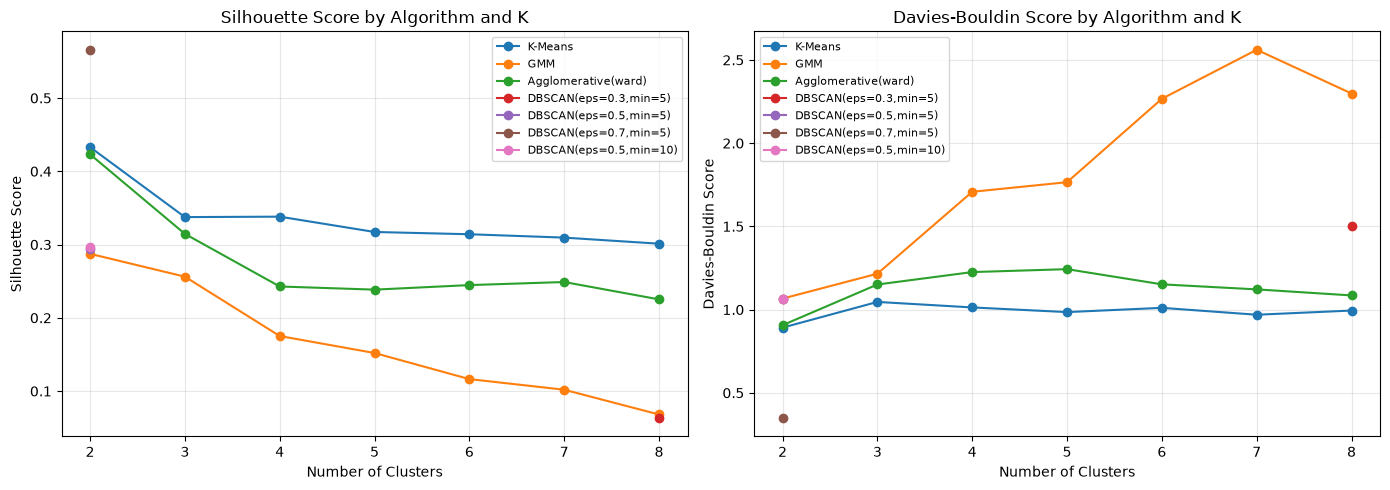

In [4]:
# Clustering comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Filter valid configs for plotting
valid = clustering_comp[clustering_comp['silhouette_score'].notna()].copy()

# Silhouette by algorithm
for algo in valid['algorithm'].unique():
    subset = valid[valid['algorithm'] == algo]
    axes[0].plot(subset['n_clusters'], subset['silhouette_score'], 'o-', label=algo)
axes[0].set_xlabel('Number of Clusters')
axes[0].set_ylabel('Silhouette Score')
axes[0].set_title('Silhouette Score by Algorithm and K')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Davies-Bouldin by algorithm
for algo in valid['algorithm'].unique():
    subset = valid[valid['algorithm'] == algo]
    if 'davies_bouldin_score' in subset.columns:
        axes[1].plot(subset['n_clusters'], subset['davies_bouldin_score'], 'o-', label=algo)
axes[1].set_xlabel('Number of Clusters')
axes[1].set_ylabel('Davies-Bouldin Score')
axes[1].set_title('Davies-Bouldin Score by Algorithm and K')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES_MC / 'clustering_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Classification Model Comparison

So sánh DummyClassifier (baseline), Logistic Regression, Decision Tree và Random Forest.

In [5]:
classification_comp = build_classification_comparison()
classification_comp.to_csv(TABLES_MC / 'classification_model_comparison.csv', index=False)

display_cols = ['model', 'cv_f1_mean', 'cv_f1_std', 'test_f1', 'test_accuracy',
                'test_precision', 'test_recall', 'test_roc_auc', 'is_selected']
available_cols = [c for c in display_cols if c in classification_comp.columns]
print("Classification Model Comparison:")
display(classification_comp[available_cols])

# Highlight baseline vs best
dummy_row = classification_comp[classification_comp['model'].str.contains('Dummy', case=False, na=False)]
selected_row = classification_comp[classification_comp['is_selected'].astype(bool)]
if len(dummy_row) > 0 and len(selected_row) > 0:
    d = dummy_row.iloc[0]
    s = selected_row.iloc[0]
    dummy_f1 = d.get('cv_f1_mean', d.get('cv_f1', 0))
    sel_f1 = s.get('cv_f1_mean', s.get('cv_f1', 0))
    print(f"\nBaseline (Dummy) CV F1: {dummy_f1:.4f}")
    print(f"Selected ({s['model']}) CV F1: {sel_f1:.4f}")
    if sel_f1 > dummy_f1:
        print(f"  → Selected model vượt baseline +{sel_f1-dummy_f1:.4f}")
    else:
        print(f"  ⚠ Selected model KHÔNG vượt baseline trên CV F1")

Classification Model Comparison:


,model,cv_f1_mean,cv_f1_std,test_f1,test_accuracy,test_precision,test_recall,test_roc_auc,is_selected
0,DummyClassifier,0.7259,0.0003,0.7259,0.5697,0.5697,1.0000,0.5000,False
1,LogisticRegression,0.7069,0.0206,0.7471,0.7136,0.7520,0.7422,0.7761,False
2,DecisionTree,0.6978,0.0222,0.6898,0.6810,0.7735,0.6224,0.7424,False
3,RandomForest,0.7102,0.0175,0.7375,0.7033,0.7434,0.7318,0.7756,True



Baseline (Dummy) CV F1: 0.7259
Selected (RandomForest) CV F1: 0.7102
  ⚠ Selected model KHÔNG vượt baseline trên CV F1


### Nhận xét Classification

**Protocol đánh giá:**
- Model selection dựa trên Stratified K-Fold CV F1-score trên tập train
- DummyClassifier (most_frequent) là baseline — nếu learned model không vượt Dummy thì chưa có giá trị dự đoán thực sự
- Threshold = 0.5 (default) — chưa tối ưu cho nghiệp vụ vì thiếu chi phí FP/FN

**Hạn chế:**
- Single cutoff random customer split — không chứng minh generalization temporal
- Chưa có hyperparameter grid search đầy đủ
- class_weight=balanced được dùng nhưng cần đánh giá tác động rõ hơn

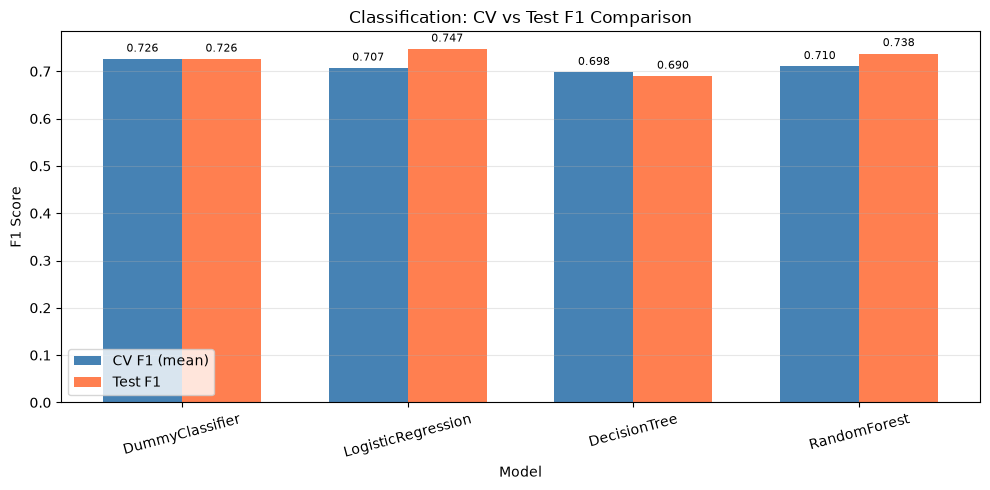

In [6]:
# CV vs Test comparison
fig, ax = plt.subplots(figsize=(10, 5))
models = classification_comp['model'].values
x = np.arange(len(models))
width = 0.35

cv_f1 = classification_comp.get('cv_f1_mean', classification_comp.get('cv_f1', pd.Series([0]*len(models)))).values
test_f1 = classification_comp.get('test_f1', pd.Series([0]*len(models))).values

bars1 = ax.bar(x - width/2, cv_f1, width, label='CV F1 (mean)', color='steelblue')
bars2 = ax.bar(x + width/2, test_f1, width, label='Test F1', color='coral')
ax.set_xlabel('Model')
ax.set_ylabel('F1 Score')
ax.set_title('Classification: CV vs Test F1 Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_MC / 'classification_cv_vs_test.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Association Rules Comparison

So sánh Apriori và FP-Growth trên cùng basket matrix, cùng min_support và min_confidence.

In [7]:
assoc_comp = build_association_comparison()
assoc_comp.to_csv(TABLES_MC / 'association_rules_comparison.csv', index=False)

print("Association Rules Algorithm Comparison:")
display(assoc_comp)

Association Rules Algorithm Comparison:


,algorithm,min_support,min_confidence,runtime_seconds,frequent_itemset_count,rule_count,valid_rule_count,max_itemset_size,max_rule_lift,is_selected,selection_reason
0,Apriori,0.0200,0.5000,3.0051,389,61,61,3,18.2311,True,Apriori and FP-Growth produce mathematically i...
1,FP-Growth,0.0200,0.5000,3.1048,389,61,61,3,18.2311,False,


### Nhận xét Association Rules

**Kỳ vọng:**
- Apriori và FP-Growth giải cùng bài toán frequent itemsets → kết quả phải tương đương
- Runtime có thể khác nhau tùy thuộc vào cấu trúc dữ liệu (mật độ, số items)
- FP-Growth thường nhanh hơn trên dữ liệu thưa, nhưng không luôn đúng

**Validation:**
- Cùng số frequent itemsets → PASS
- Cùng số rules → PASS (hoặc kiểm tra nội dung thực nếu khác)
- lift > 1 cho tất cả selected rules → mối liên hệ dương

## 5. Model Artifacts Verification

In [8]:
artifact_checks = verify_model_artifacts()
for c in artifact_checks:
    print(c)
if any('[FAIL]' in c for c in artifact_checks):
    raise RuntimeError(f"Artifact verification failed: {artifact_checks}")
print("\n[OK] All model artifacts verified.")

[PASS] Clustering model loadable: KMeans
[PASS] Classification pipeline loadable: Pipeline
[PASS] Classification metadata: selected=RandomForest

[OK] All model artifacts verified.


## 6. Business Insights

Insights được sinh từ kết quả thực tế của các models, không hard-code.

In [9]:
insights = generate_all_insights()

# Save insights tables
for name, df_insight in insights.items():
    if isinstance(df_insight, pd.DataFrame) and not df_insight.empty:
        path = OUTPUTS_DIR / 'tables' / 'insights' / f'{name}.csv'
        path.parent.mkdir(parents=True, exist_ok=True)
        df_insight.to_csv(path, index=False)
        print(f"[OK] Saved {name}.csv ({len(df_insight)} rows)")
    elif isinstance(df_insight, dict):
        print(f"[INFO] {name}: {len(df_insight)} entries")

[OK] Saved customer_segment_insights.csv (2 rows)
[OK] Saved customer_segment_action_plan.csv (4 rows)
[OK] Saved product_association_insights.csv (20 rows)
[OK] Saved classification_feature_insights.csv (43 rows)


## 7. Generate Report and Manifest

In [10]:
# Centralized Export of all Step 07 synchronized outputs (tables, 10 figures, report, summary, manifest)
export_res = export_all_step_07_outputs(
    clust_comp=clustering_comp,
    class_comp=classification_comp,
    assoc_comp=assoc_comp,
    seg_insights=insights.get('customer_segment_insights'),
    action_plan=insights.get('customer_segment_action_plan'),
    prod_insights=insights.get('product_association_insights'),
    feat_insights=insights.get('classification_feature_insights'),
    save_figures=True
)
print('[OK] Step 07 synchronized export complete.')

# Check manifest validation status
manifest = export_res['manifest']
if manifest.get('validation_status') != 'PASS':
    missing = manifest.get('missing_files', [])
    raise RuntimeError(f"Step 07 FAILED: pipeline_manifest.json validation_status is 'FAIL'. Missing files: {missing}")
print(f"[OK] Manifest validated with status: PASS")

[OK] Step 07 synchronized export complete.
[OK] Manifest validated with status: PASS


## 8. Tổng kết

### Các quyết định cuối cùng:
1. **Clustering**: Model được chọn dựa trên ranking tổng hợp internal metrics + cluster size distribution
2. **Classification**: Model được chọn dựa trên CV F1-score (không dùng test set để chọn)
3. **Association Rules**: Cả Apriori và FP-Growth đều hợp lệ; chọn theo runtime + equivalence check

### Hạn chế chung:
- Single UK retailer — kết quả không tự động generalize sang retailer khác
- Historical data (2010-12-01 → 2011-12-09) — chưa đánh giá temporal drift
- Missing CustomerID (24.93%) — selection bias trong tập khách hàng
- Không có margin/campaign response data — chưa tính ROI thực tế
- Không chứng minh nhân quả — chỉ là mối liên hệ thống kê

### Items cần nhóm bổ sung (NEEDS_USER_INPUT):
- Tên và đóng góp thành viên
- Peer assessment
- AI disclosure

In [11]:
manifest_data = json.loads((EVIDENCE_DIR / 'pipeline_manifest.json').read_text(encoding='utf-8'))
if manifest_data.get('validation_status') != 'PASS':
    raise RuntimeError(f"Step 07 FAILED: pipeline_manifest.json has validation_status='FAIL'!")

print("=" * 60)
print("  07. MODEL COMPARISON AND INSIGHTS — COMPLETE")
print("=" * 60)
print(f"\nOutputs:")
print(f"  Tables: {TABLES_MC}")
print(f"  Figures: {FIGURES_MC}")
print(f"  Report: {REPORTS_DIR / '07_model_comparison_and_insights.md'}")
print(f"  Manifest: {EVIDENCE_DIR / 'pipeline_manifest.json'}")

  07. MODEL COMPARISON AND INSIGHTS — COMPLETE

Outputs:
  Tables: C:\Users\HUNG\Downloads\test\Data-mining\outputs\tables\model_comparison
  Figures: C:\Users\HUNG\Downloads\test\Data-mining\outputs\figures\model_comparison
  Report: C:\Users\HUNG\Downloads\test\Data-mining\outputs\reports\07_model_comparison_and_insights.md
  Manifest: C:\Users\HUNG\Downloads\test\Data-mining\outputs\evidence\pipeline_manifest.json
